<a href="https://colab.research.google.com/github/AnikethKotamraju/Advanced-Cricket-Analytics/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

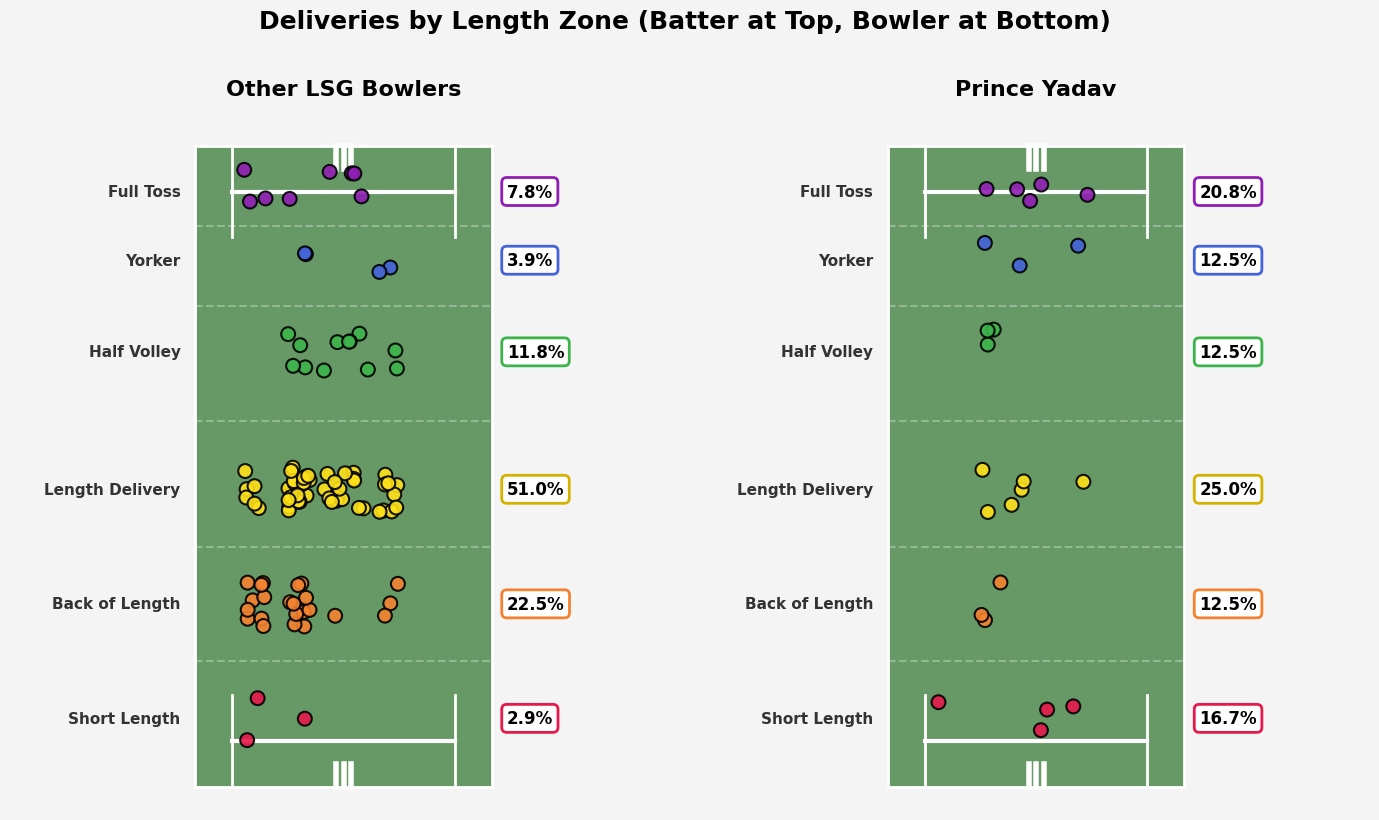

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Load data
df = pd.read_csv('LSGvsPBKS.csv')
lsg_bowling = df[df['Bowling Team'] == 'Lucknow Super Giants'].copy()

# Group the bowlers
lsg_bowling['Bowler_Group'] = lsg_bowling['Bowler'].apply(
    lambda x: 'Prince Yadav' if x == 'Prince Yadav' else 'Other Bowlers'
)

# 2. Mapping for Coordinates (Inverted Y-Axis: 0 is Bowler, 12 is Batter)
line_map = {
    'Wide Off': -1.2, 'Outside Off': -0.6, 'Off stump': -0.2,
    'Middle stump': 0, 'Leg stump': 0.2, 'Outside Leg': 0.6
}
length_map = {
    'Full Toss': 12, 'Yorker': 10.5, 'Half Volley': 8.5,
    'Length Delivery': 5.5, 'Back of Length': 3, 'Short Length': 0.5
}

# Distinct bright colors for zones
color_map = {
    'Short Length': '#e6194b',       # Red
    'Back of Length': '#f58231',     # Orange
    'Length Delivery': '#ffe119',    # Yellow
    'Half Volley': '#3cb44b',        # Green
    'Yorker': '#4363d8',             # Blue
    'Full Toss': '#911eb4'           # Purple
}

# Apply mappings
lsg_bowling['Pitch_X'] = lsg_bowling['Pitching Line'].map(line_map)
lsg_bowling['Pitch_Y'] = lsg_bowling['Pitching Length'].map(length_map)
lsg_bowling['Color'] = lsg_bowling['Pitching Length'].map(color_map)

# Add slight random jitter so overlapping balls are visible
np.random.seed(42)
lsg_bowling['Pitch_X'] += np.random.uniform(-0.15, 0.15, size=len(lsg_bowling))
lsg_bowling['Pitch_Y'] += np.random.uniform(-0.5, 0.5, size=len(lsg_bowling))

# Split data for plotting
others = lsg_bowling[lsg_bowling['Bowler_Group'] == 'Other Bowlers']
py = lsg_bowling[lsg_bowling['Bowler_Group'] == 'Prince Yadav']

# Calculate Percentages for the badges
others_len_pct = others['Pitching Length'].value_counts(normalize=True) * 100
py_len_pct = py['Pitching Length'].value_counts(normalize=True) * 100

# 3. Function to draw the TV-style cricket pitch
def draw_inverted_pitch(ax, title, data_pct):
    # Pitch background (Green rectangle)
    pitch = patches.Rectangle((-2, -1), 4, 14, linewidth=2, edgecolor='white', facecolor='#669966', zorder=1)
    ax.add_patch(pitch)

    # Bowling Crease (Bottom) & Batting Crease (Top)
    ax.plot([-1.5, 1.5], [0, 0], color='white', linewidth=3, zorder=2)
    ax.plot([-1.5, 1.5], [12, 12], color='white', linewidth=3, zorder=2)

    # Return Creases
    ax.plot([-1.5, -1.5], [-1, 1], color='white', linewidth=2, zorder=2)
    ax.plot([1.5, 1.5], [-1, 1], color='white', linewidth=2, zorder=2)
    ax.plot([-1.5, -1.5], [11, 13], color='white', linewidth=2, zorder=2)
    ax.plot([1.5, 1.5], [11, 13], color='white', linewidth=2, zorder=2)

    # Stumps (Batter end - Top) & (Bowler end - Bottom)
    ax.plot([-0.1, -0.1], [12.5, 13], color='white', linewidth=4, zorder=2)
    ax.plot([0, 0], [12.5, 13], color='white', linewidth=4, zorder=2)
    ax.plot([0.1, 0.1], [12.5, 13], color='white', linewidth=4, zorder=2)
    ax.plot([-0.1, -0.1], [-1, -0.5], color='white', linewidth=4, zorder=2)
    ax.plot([0, 0], [-1, -0.5], color='white', linewidth=4, zorder=2)
    ax.plot([0.1, 0.1], [-1, -0.5], color='white', linewidth=4, zorder=2)

    # Zones definition: (Name, Y-coordinate for text, Color, Y-coordinate for dashed divider)
    zones = [
        ('Short Length', 0.5, '#e6194b', 1.75),
        ('Back of Length', 3, '#f58231', 4.25),
        ('Length Delivery', 5.5, '#ffe119', 7.0),
        ('Half Volley', 8.5, '#3cb44b', 9.5),
        ('Yorker', 10.5, '#4363d8', 11.25),
        ('Full Toss', 12, '#911eb4', None)
    ]

    # Add horizontal zone dividers and text annotations
    for name, y, col, divider_y in zones:
        pct = data_pct.get(name, 0)

        # Faint dashed line to separate zones visually
        if divider_y is not None:
            ax.plot([-2, 2], [divider_y, divider_y], color='white', linestyle='--', alpha=0.3, zorder=2)

        # Left side: Zone Name
        ax.text(-2.2, y, name, va='center', ha='right', fontsize=11, color='#333333', fontweight='bold')

        # Right side: Percentage colored block
        if pct > 0:
            # Slightly darker border for yellow to make it pop, otherwise use the zone color
            edge_color = '#d4b200' if name == 'Length Delivery' else col
            bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec=edge_color, lw=2, alpha=1)
            ax.text(2.2, y, f'{pct:.1f}%', va='center', ha='left', fontsize=12, color='black', fontweight='bold', bbox=bbox_props)

    ax.set_xlim(-4.5, 4.5)
    ax.set_ylim(-1.5, 13.5)
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)

# 4. Create the final Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor='#f4f4f4')

# Plot Other Bowlers
draw_inverted_pitch(axes[0], 'Other LSG Bowlers', others_len_pct)
axes[0].scatter(others['Pitch_X'], others['Pitch_Y'], c=others['Color'], s=100, edgecolors='black', linewidth=1.5, zorder=3, alpha=0.9)

# Plot Prince Yadav
draw_inverted_pitch(axes[1], 'Prince Yadav', py_len_pct)
axes[1].scatter(py['Pitch_X'], py['Pitch_Y'], c=py['Color'], s=100, edgecolors='black', linewidth=1.5, zorder=3, alpha=0.9)

# Add Main Title
fig.suptitle("Deliveries by Length Zone (Batter at Top, Bowler at Bottom)", fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show() # Renders the plot directly in the Colab output cell